# Im(r_p) Dispersion Maps: Extracted q_p vs Simulated Multilayer Reflection

For each of the 3 linecut datasets, compute Im(r_p)(q, omega) for the appropriate
layer stack (graphene-only on SiO2/Si for graphene_3x1_manual; MoO3/graphene/SiO2/Si
for graphene_4x1_manual's lp1="edge"/lp2="interior") using
`snippet.nearfield.rp_schematic` (same tool `response_Shizhe.ipynb` uses for doped
graphene/CIPS, and the same `NearFieldOptics.Materials.AnisotropicMaterial` +
`LayeredMediaTM` engine `CrSBr_Rp_calculation` uses for CrSBr), and overlay the
q_p extracted this session (CHT/Hankel/1-sqrtx/FFT, from
`data/fit_results_graphene_*.pkl`) as scatter points on top.

E_F is fit **independently per method per dataset** (12 fits total) rather than
one E_F per dataset -- CHT/Hankel/1-sqrtx/FFT don't extract exactly the same q_p
at a given wn, so forcing one E_F onto all 4 makes 3 of the 4 visibly miss the
ridge. gamma=20cm-1 is kept fixed (per the reference figures) for all fits.

In [1]:
import sys, os
sys.path.append('.')
sys.path.append('/Users/shizhe/envsetting')
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from snippet.nearfield import rp_schematic
from NearFieldOptics import Materials as M

plt.rcParams.update({
    'font.size': 12, 'font.family': 'Arial',
    'axes.linewidth': 1.5, 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True,
    'ytick.right': True
})

SAVE_DIR = 'figures/rp_dispersion'
os.makedirs(SAVE_DIR, exist_ok=True)
GAMMA = 20  # cm^-1, fixed for all fits per the reference figures


<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "PMMA_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "sio2_300nm_extracted_epsilon_cone_A=2a.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_230K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_30K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Erik_BSTS_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_295K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_360K.csv"...
<material_types.Ta

## 1. Materials

MoO3: anisotropic phonon material. `reflection_p`'s underlying uniaxial TM solver only ever
uses the x/y **average** of the principal epsilon tensor
(`NearFieldOptics.Materials.material_types.BaseAnisotropicMaterial.epsilon` ->
`ordinary_epsilon` -> mean of `diag[:2]`) -- there is no azimuthal-angle parameter, so it
cannot represent a true direction-dependent biaxial response. We therefore build two
uniaxial candidates (x=y=a-axis, or x=y=c-axis) and compare both, since the true
crystalline orientation of this flake relative to the linecut direction is not currently
known. Phonon params per axis are `(omega_LO, gamma_LO, omega_TO, gamma_TO)` tuples, taken
from Zheng et al. 2019, *Sci. Adv.* 5, eaav8690, Table S1 "this work" column (confirmed by
reading the paper's SI directly -- these are NOT the same as the
`10.1002/adma.201908176` values originally cited here, though `x`/`z` happen to be
numerically identical between the two references).

In [2]:
# MoO3, Zheng et al. 2019 Sci. Adv. 5, eaav8690, Table S1 "this work" column:
#   x [100] (a-axis): eps_inf=4.0, wLO=972 gLO=4 wTO=820 gTO=4
#   y [001] (c-axis): eps_inf=5.2, wLO=851 gLO=4 wTO=545 gTO=4
#   z [010] (b-axis, out-of-plane): eps_inf=2.4, wLO=1004 gLO=2 wTO=958 gTO=2
# eps_infinity=[4, 5.2, 2.4] kept per-axis (unaffected by which in-plane axis is chosen
# below) for both MoO3_a/MoO3_c -- see markdown above for why only a uniaxial x=y choice
# is meaningful here.
phonon_a = [(972, 4, 820, 4)]
phonon_c = [(851, 4, 545, 4)]
phonon_b = [(1004, 2, 958, 2)]
MoO3_a = M.AnisotropicMaterial(eps_infinity=[4, 5.2, 2.4], phonon_params=[phonon_a, phonon_a, phonon_b])
MoO3_c = M.AnisotropicMaterial(eps_infinity=[4, 5.2, 2.4], phonon_params=[phonon_c, phonon_c, phonon_b])

# SiO2 300nm on Si substrate -- shared by both stacks below
materials_3x1 = {'SiO2': M.SiO2_300nm}
materials_4x1_a = {'SiO2': M.SiO2_300nm, 'MoO3': MoO3_a}
materials_4x1_c = {'SiO2': M.SiO2_300nm, 'MoO3': MoO3_c}
SUBS = M.Si

stack_3x1 = ['graphene', ('SiO2', 300)]
stack_4x1 = [('MoO3', 4.2), 'graphene', ('SiO2', 300)]


## 2. Build overlay points from the fitted q_p (this session's pkl results)

`rp_schematic(..., pts=pts_dict, pts_chn='cht')` expects `pts_dict['cht_qp']` to be a DataFrame with `q(cm-1)` and `w(cm-1)` columns.

In [3]:
METHODS = ['cht', 'hankel', 'sqrtx', 'fft']

def build_pts(pkl_path):
    """data/fit_results_graphene_*.pkl -> {'cht_qp': df, 'hankel_qp': df, 'sqrtx_qp': df, 'fft_qp': df}"""
    with open(pkl_path, 'rb') as f:
        pkl = pickle.load(f)
    out = {}
    for m in METHODS:
        rows = []
        for wn_key, results in pkl.items():
            q_1e5 = results[m]['q_p_1e5cm-1']
            if q_1e5 is None:
                continue
            rows.append({'w(cm-1)': int(wn_key.replace('cm-1', '')), 'q(cm-1)': q_1e5 * 1e5})
        out[f'{m}_qp'] = pd.DataFrame(rows).sort_values('w(cm-1)').reset_index(drop=True)
    return out

pts_3x1 = build_pts('data/fit_results_graphene_3x1_manual.pkl')
pts_lp1 = build_pts('data/fit_results_graphene_4x1_lp1.pkl')
pts_lp2 = build_pts('data/fit_results_graphene_4x1_lp2.pkl')

for name, pts in [('3x1_manual', pts_3x1), ('4x1_lp1 (edge)', pts_lp1), ('4x1_lp2 (interior)', pts_lp2)]:
    print(name, '-- cht points:', len(pts['cht_qp']), 'wn range:',
          pts['cht_qp']['w(cm-1)'].min(), '-', pts['cht_qp']['w(cm-1)'].max())


3x1_manual -- cht points: 15 wn range: 860 - 1000
4x1_lp1 (edge) -- cht points: 15 wn range: 860 - 1000
4x1_lp2 (interior) -- cht points: 15 wn range: 860 - 1000


## 3. Per-method E_F fit

For a trial E_F, evaluate Im(r_p) at each data point's exact (q, w) (diagonal of the frequency x q grid `reflection_p` returns) and sum -- this is maximized when the data points sit on the bright dispersion ridge. `scipy.optimize.minimize_scalar` (bounded, 1D) finds the E_F that maximizes this sum. gamma stays fixed at `GAMMA` throughout.

In [4]:
def build_tm_layers(stack, materials, Ef, gamma):
    Efcm = Ef * 8065.5
    graphene = M.SingleLayerGraphene(chemical_potential=Efcm, gamma=gamma)
    tm_layers = []
    for item in stack:
        if isinstance(item, str) and item.lower() == 'graphene':
            tm_layers.append(graphene)
        else:
            name, thickness_nm = item
            tm_layers.append((materials[name], thickness_nm * 1e-7))
    return tm_layers

def fit_Ef(stack, materials, subs, w_data, q_data, gamma=GAMMA, ef_bounds=(0.1, 1.5)):
    w_data = np.asarray(w_data, dtype=float)
    q_data = np.asarray(q_data, dtype=float)

    def neg_score(Ef):
        layersTM = M.LayeredMediaTM(*build_tm_layers(stack, materials, Ef, gamma), exit=subs)
        rp_grid = np.asarray(layersTM.reflection_p(w_data, q=q_data))
        return -float(np.sum(np.imag(np.diag(rp_grid))))

    res = minimize_scalar(neg_score, bounds=ef_bounds, method='bounded')
    return float(res.x)

def fit_all_methods(stack, materials, pts):
    ef_by_method = {}
    for m in METHODS:
        df = pts[f'{m}_qp']
        ef_by_method[m] = fit_Ef(stack, materials, SUBS, df['w(cm-1)'].values, df['q(cm-1)'].values)
    return ef_by_method

ef_3x1 = fit_all_methods(stack_3x1, materials_3x1, pts_3x1)
ef_lp1_a = fit_all_methods(stack_4x1, materials_4x1_a, pts_lp1)
ef_lp1_c = fit_all_methods(stack_4x1, materials_4x1_c, pts_lp1)
ef_lp2_a = fit_all_methods(stack_4x1, materials_4x1_a, pts_lp2)
ef_lp2_c = fit_all_methods(stack_4x1, materials_4x1_c, pts_lp2)

print('E_F (eV), 3x1_manual (Gr/SiO2/Si):        ', {k: round(v, 3) for k, v in ef_3x1.items()})
print('E_F (eV), 4x1 lp1 (MoO3(a)/edge):         ', {k: round(v, 3) for k, v in ef_lp1_a.items()})
print('E_F (eV), 4x1 lp1 (MoO3(c)/edge):         ', {k: round(v, 3) for k, v in ef_lp1_c.items()})
print('E_F (eV), 4x1 lp2 (MoO3(a)/interior):     ', {k: round(v, 3) for k, v in ef_lp2_a.items()})
print('E_F (eV), 4x1 lp2 (MoO3(c)/interior):     ', {k: round(v, 3) for k, v in ef_lp2_c.items()})


E_F (eV), 3x1_manual (Gr/SiO2/Si):         {'cht': 0.507, 'hankel': 0.497, 'sqrtx': 0.498, 'fft': 0.647}
E_F (eV), 4x1 lp1 (MoO3(a)/edge):          {'cht': 0.771, 'hankel': 0.773, 'sqrtx': 0.768, 'fft': 0.704}
E_F (eV), 4x1 lp1 (MoO3(c)/edge):          {'cht': 0.839, 'hankel': 0.829, 'sqrtx': 0.837, 'fft': 0.735}
E_F (eV), 4x1 lp2 (MoO3(a)/interior):      {'cht': 0.723, 'hankel': 0.915, 'sqrtx': 0.96, 'fft': 0.51}
E_F (eV), 4x1 lp2 (MoO3(c)/interior):      {'cht': 0.738, 'hankel': 0.96, 'sqrtx': 0.959, 'fft': 0.795}


## 4. graphene_3x1_manual -- Gr/SiO2(300nm)/Si (no MoO3)

Saved figures/rp_dispersion/graphene_3x1_manual_rp_dispersion.png


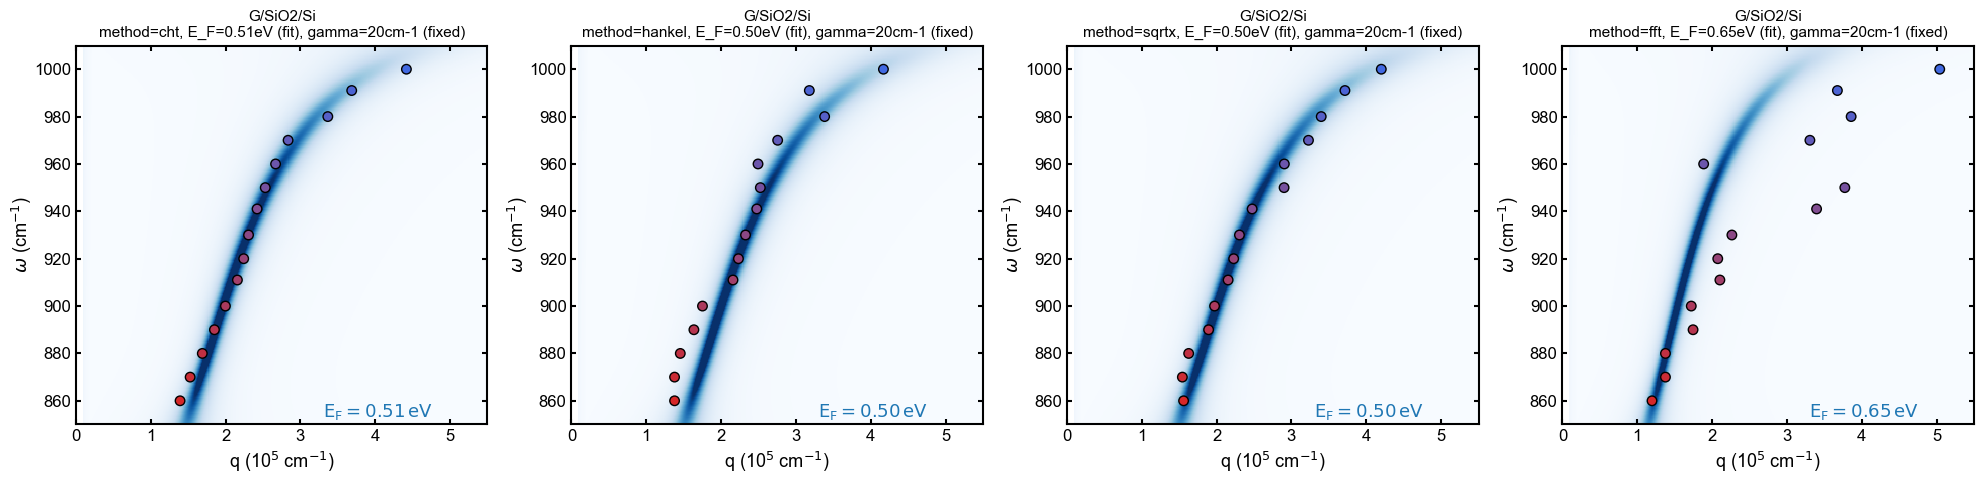

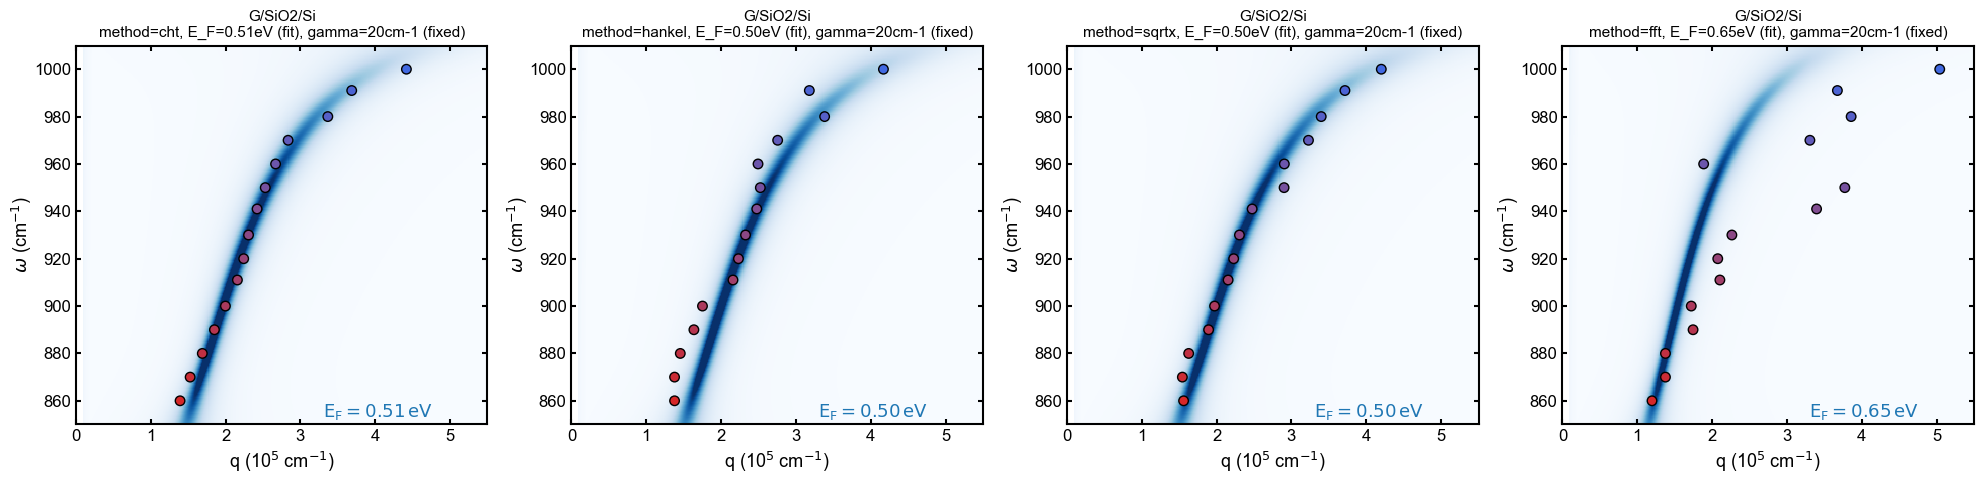

In [5]:
FREQS = np.linspace(850, 1010, 300)
QS = np.linspace(1e4, 5.5e5, 400)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, method in zip(axes, METHODS):
    rp_schematic(stack_3x1, materials_3x1, subs=SUBS, freqs=FREQS, qs=QS,
                 Ef=ef_3x1[method], gamma=GAMMA, figAx=(fig, ax), vmin=0, vmax=8,
                 pts=pts_3x1, pts_chn=method, show_Ef=True, ytickspacing=20)
    ax.set_title(f'G/SiO2/Si\nmethod={method}, E_F={ef_3x1[method]:.2f}eV (fit), gamma={GAMMA}cm-1 (fixed)', fontsize=11)

fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/graphene_3x1_manual_rp_dispersion.png', dpi=200, bbox_inches='tight')
print(f'Saved {SAVE_DIR}/graphene_3x1_manual_rp_dispersion.png')
fig


## 5. graphene_4x1_manual lp1 ("MoO3 edge") -- MoO3(4.2nm)/Gr/SiO2(300nm)/Si

Saved figures/rp_dispersion/graphene_4x1_lp1_edge_rp_dispersion_MoO3a.png


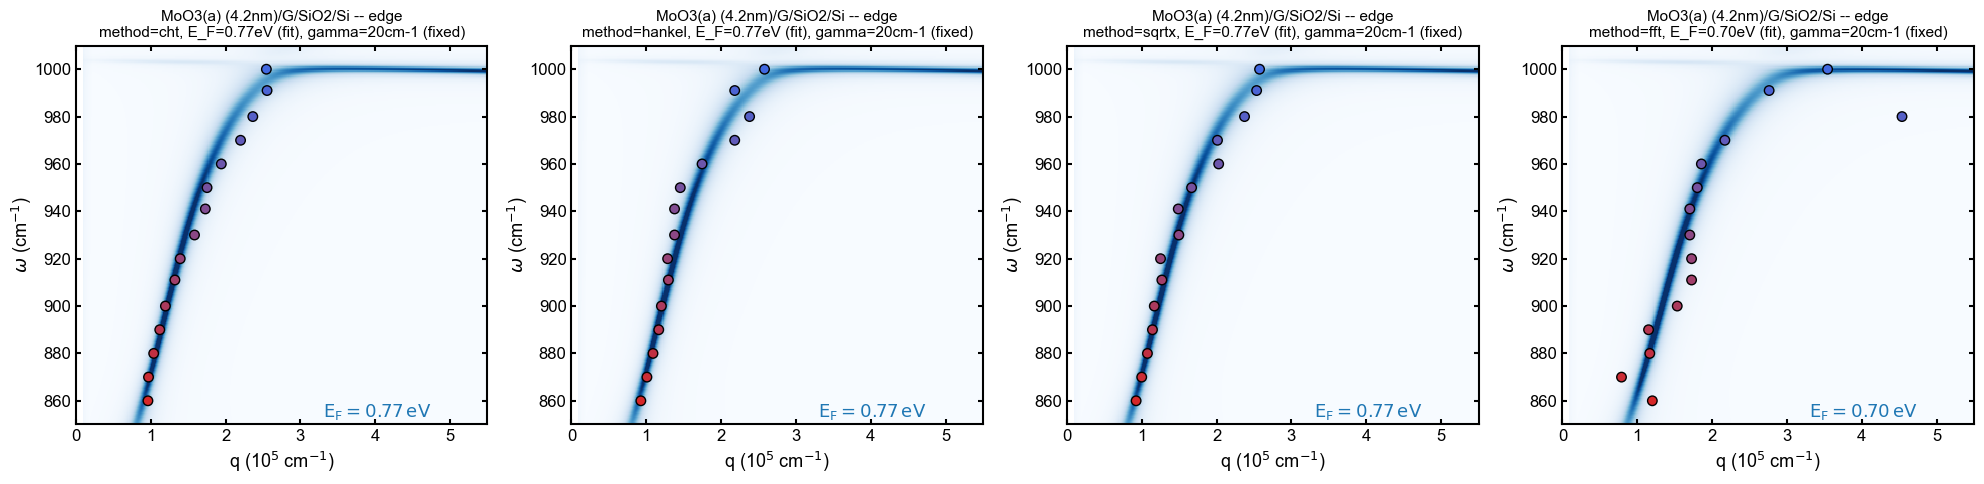

Saved figures/rp_dispersion/graphene_4x1_lp1_edge_rp_dispersion_MoO3c.png


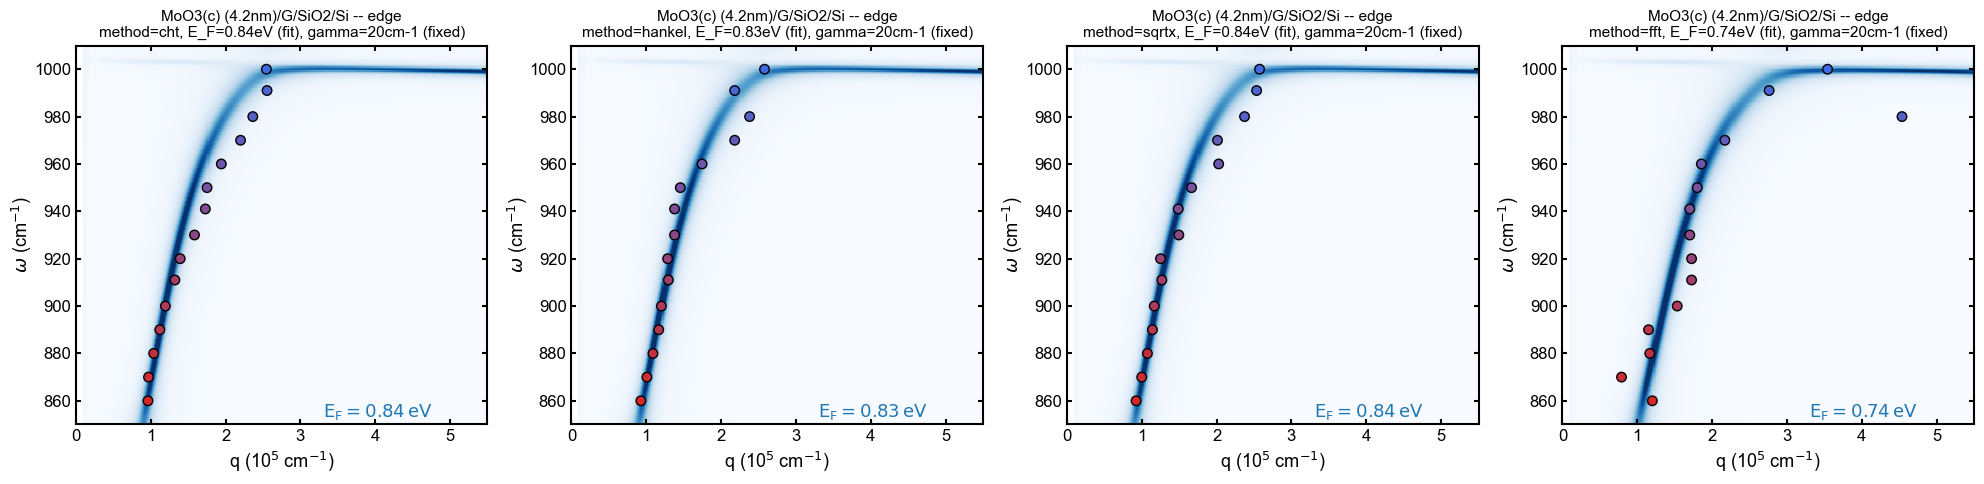

In [6]:
FREQS = np.linspace(850, 1010, 300)
QS = np.linspace(1e4, 5.5e5, 400)

for axis_label, materials_4x1, ef_lp1 in [('a', materials_4x1_a, ef_lp1_a), ('c', materials_4x1_c, ef_lp1_c)]:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, method in zip(axes, METHODS):
        rp_schematic(stack_4x1, materials_4x1, subs=SUBS, freqs=FREQS, qs=QS,
                     Ef=ef_lp1[method], gamma=GAMMA, figAx=(fig, ax), vmin=0, vmax=8,
                     pts=pts_lp1, pts_chn=method, show_Ef=True, ytickspacing=20)
        ax.set_title(f'MoO3({axis_label}) (4.2nm)/G/SiO2/Si -- edge\nmethod={method}, E_F={ef_lp1[method]:.2f}eV (fit), gamma={GAMMA}cm-1 (fixed)', fontsize=11)

    fig.tight_layout()
    out_path = f'{SAVE_DIR}/graphene_4x1_lp1_edge_rp_dispersion_MoO3{axis_label}.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f'Saved {out_path}')
    display(fig)
    plt.close(fig)


## 6. graphene_4x1_manual lp2 ("MoO3 interior") -- MoO3(4.2nm)/Gr/SiO2(300nm)/Si

Saved figures/rp_dispersion/graphene_4x1_lp2_interior_rp_dispersion_MoO3a.png


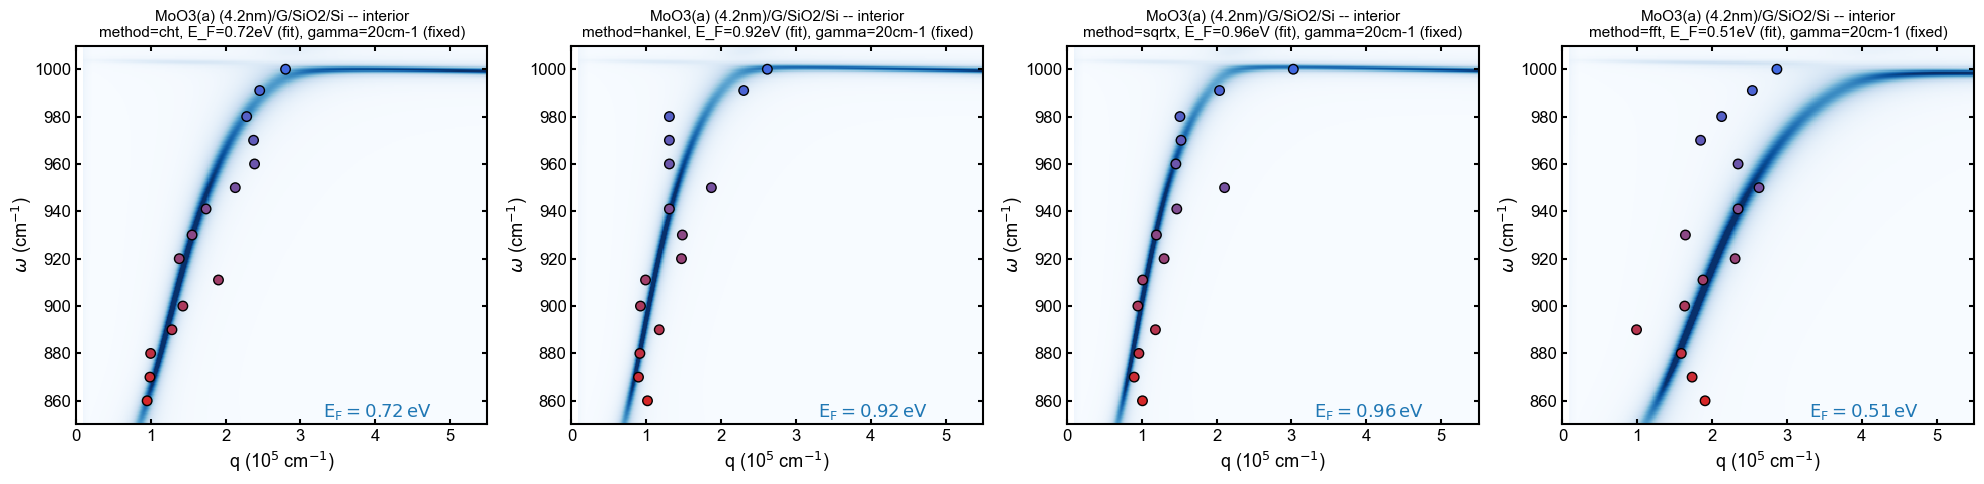

Saved figures/rp_dispersion/graphene_4x1_lp2_interior_rp_dispersion_MoO3c.png


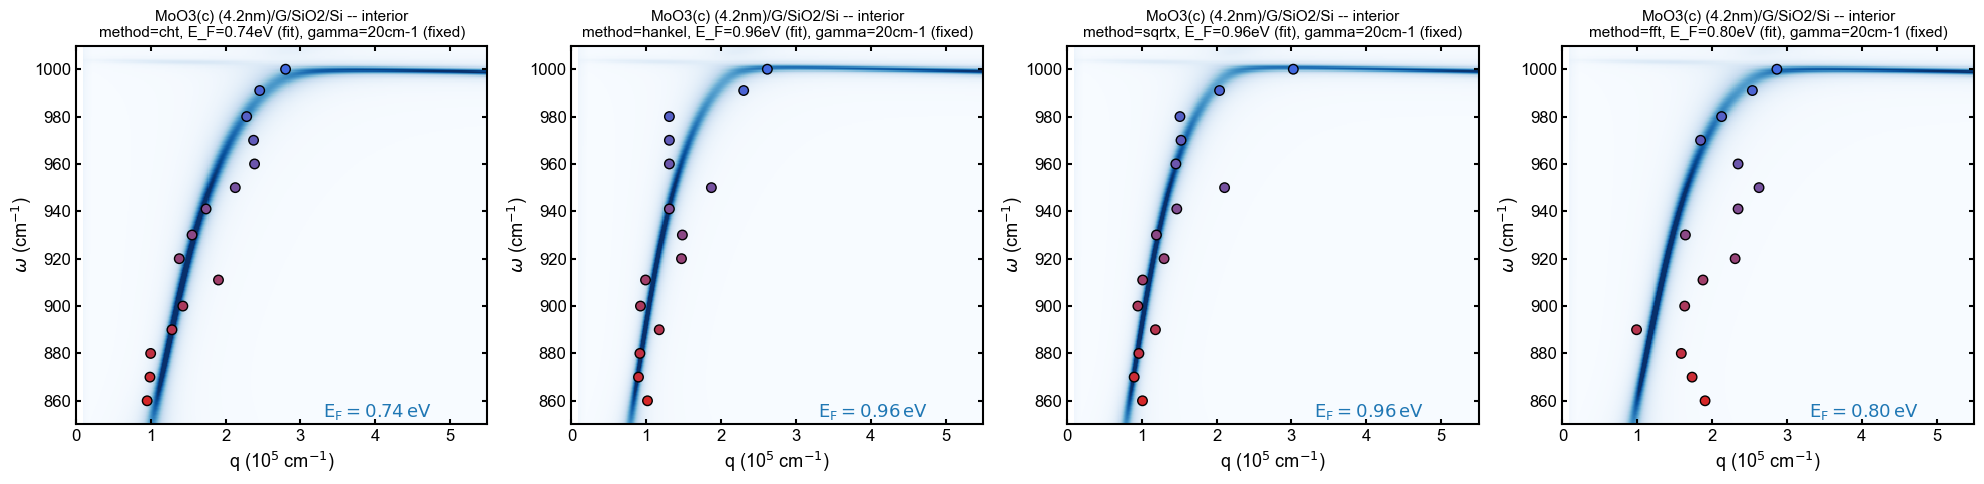

In [7]:
for axis_label, materials_4x1, ef_lp2 in [('a', materials_4x1_a, ef_lp2_a), ('c', materials_4x1_c, ef_lp2_c)]:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, method in zip(axes, METHODS):
        rp_schematic(stack_4x1, materials_4x1, subs=SUBS, freqs=FREQS, qs=QS,
                     Ef=ef_lp2[method], gamma=GAMMA, figAx=(fig, ax), vmin=0, vmax=8,
                     pts=pts_lp2, pts_chn=method, show_Ef=True, ytickspacing=20)
        ax.set_title(f'MoO3({axis_label}) (4.2nm)/G/SiO2/Si -- interior\nmethod={method}, E_F={ef_lp2[method]:.2f}eV (fit), gamma={GAMMA}cm-1 (fixed)', fontsize=11)

    fig.tight_layout()
    out_path = f'{SAVE_DIR}/graphene_4x1_lp2_interior_rp_dispersion_MoO3{axis_label}.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f'Saved {out_path}')
    display(fig)
    plt.close(fig)


## 7. Im(r_p) vs q lineout at fixed frequency: MoO3(a) vs MoO3(c), with FFT + identified 2q overlay

The 4-panel maps above use each axis assumption's own separately-fit E_F, which partly
compensates for the a-vs-c difference and makes it hard to see how much the axis choice
shifts the dispersion by itself. Here we fix a single **E_F=0.65eV** (top of the
Raman-measured range, a common reference point independent of any method's own fit) and
plot Im(r_p) vs q as a 1D lineout for MoO3(a) and MoO3(c) side by side, for three wn
(860/900/980cm-1).

Each wn's full raw FFT spectrum (complex-FFT) is overlaid on a `twinx()` right axis.
**Self-check finding** (verified numerically, not just eyeballed): at all three wn, the
FFT spectrum's dominant/global peak sits at ~2x the independently-established q_p from
CHT/Hankel/1-sqrtx (which agree tightly with each other) -- 860cm-1: peak=1.80 vs
2x(0.93-0.96)=1.86-1.92; 900cm-1: peak=2.49 vs 2x(1.17-1.20)=2.34-2.40; 980cm-1: peak=4.74
vs 2x(2.36-2.38)=4.72-4.76 (near-exact). So the FFT spectrum's strongest feature is the
**"2q" (tip-launched round-trip) channel, not "q" (edge-launched)** -- confirming the
long-suspected coexistence of both spatial-frequency components in the real-space signal,
and explaining why `fft`'s pkl-adopted q_p (nearest `q_guess[0]`) has repeatedly shown up
as the least reliable of the 4 methods throughout this project: at 860/900cm-1 the adopted
value isn't even a real local peak (the windowed search around `q_guess[0]` just climbs a
monotonic slope toward the dominant 2q peak and gets truncated at the window edge); at
980cm-1 it lands almost exactly on the 2q peak itself, i.e. `fft`'s "q_p" is actually 2q
mislabeled as q. The identified 2q peak is marked with a dashed vertical line and labeled
with its value on each plot below (CHT's own `|T(k)|` spectrum was tried too but dropped --
its near-k=0 log divergence and lack of a resolvable peak away from that divergence make it
uninterpretable as a simple "peak = q_p" spectrum, unlike FFT).

Saved figures/rp_dispersion/imrp_vs_q_860cm-1_MoO3_axis_compare.png


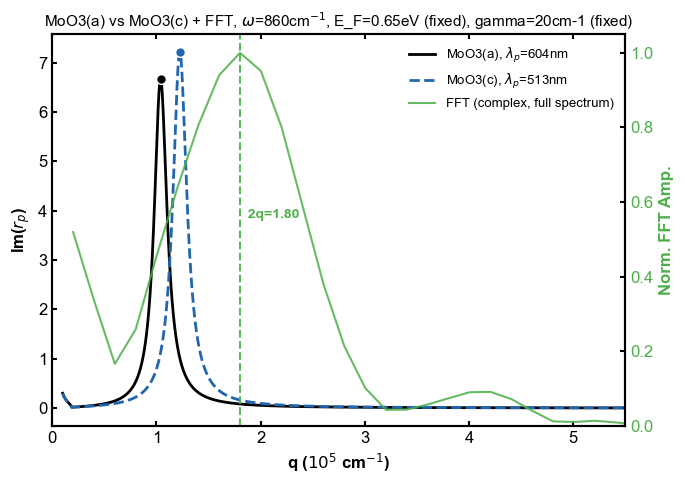

Saved figures/rp_dispersion/imrp_vs_q_900cm-1_MoO3_axis_compare.png


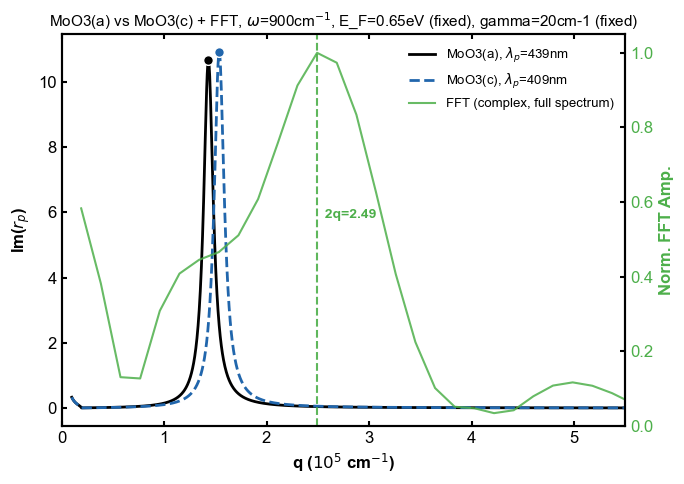

Saved figures/rp_dispersion/imrp_vs_q_980cm-1_MoO3_axis_compare.png


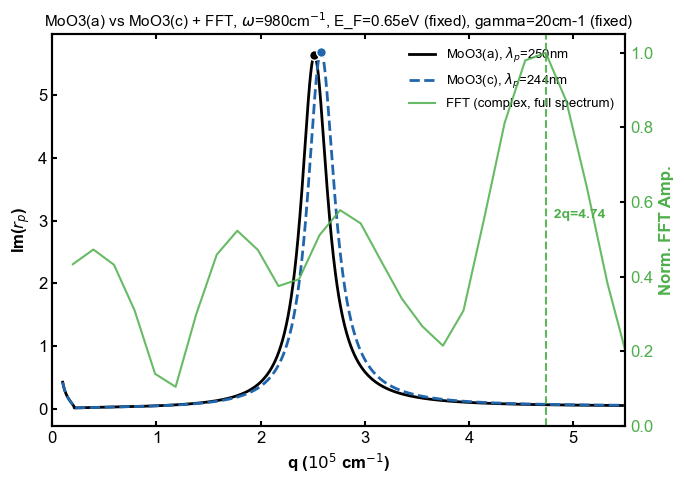

In [8]:
import nanoftir_Shizhe as nanof
from scipy.signal import savgol_filter, find_peaks

FFT_PARAMS = {
    860: dict(xr=(0.15, 1.2), q_guess=[1, 2]),
    900: dict(xr=(0.11, 1.2), q_guess=[1.2, 2.2]),
    980: dict(xr=(0.14, 1.2), q_guess=[3.5, 7.0]),
}  # copied from fitting_pipeline_graphene_4x1_lp1.ipynb's per-wn FFT cells
DATA_DIR = 'data/graphene_4x1_manual'

Ef_fixed = 0.65  # eV -- same fixed common reference used for every wn/axis-compare plot here
qs_line = np.linspace(1e4, 5.5e5, 2000)

for wn_fixed in [860, 900, 980]:
    df_wn = pd.read_csv(f'{DATA_DIR}/{wn_fixed}cm-1_AVG_lp1.csv')
    x_dist = df_wn['distance_nm'] / 1000.0
    amp_raw = df_wn['O3A']
    phase_raw = df_wn['O3P']
    window_len = min(41, len(amp_raw) if len(amp_raw) % 2 != 0 else len(amp_raw) - 1)
    amp_osc = amp_raw - savgol_filter(amp_raw, window_length=window_len, polyorder=2)

    fft_out = nanof.plot_channel_fft(
        x_dist, amp_osc, phase_raw, label='O3', wn=f'{wn_fixed}cm-1',
        xr=FFT_PARAMS[wn_fixed]['xr'], q_range=(0, 10), window='hann', pad_factor=3.0,
        q_guess=FFT_PARAMS[wn_fixed]['q_guess'], plot=False)
    q_fft_1e5 = fft_out['q_complex'] / 10.0  # um^-1 -> 1e5 cm^-1
    spec_fft = fft_out['spec_complex']

    # Identify the dominant (global, most prominent) peak in the raw spectrum -- this is
    # the "2q" tip-launched channel, confirmed by comparing against CHT/Hankel/sqrtx's q_p
    # (see markdown above): consistently ~2x the established q_p, not q itself.
    peak_idx = np.argmax(spec_fft)
    q_2q = q_fft_1e5[peak_idx]

    fig, ax = plt.subplots(figsize=(7, 5))
    for axis_label, materials_4x1, color, ls in [('a', materials_4x1_a, 'k', '-'), ('c', materials_4x1_c, '#2166ac', '--')]:
        layersTM = M.LayeredMediaTM(*build_tm_layers(stack_4x1, materials_4x1, Ef_fixed, GAMMA), exit=SUBS)
        rp_line = np.asarray(layersTM.reflection_p(float(wn_fixed), q=qs_line))
        im_rp = np.imag(rp_line)

        i_peak = np.argmax(im_rp)
        q_peak = qs_line[i_peak]
        lambda_peak_nm = 2 * np.pi / q_peak * 1e7  # cm^-1 -> nm

        ax.plot(qs_line / 1e5, im_rp, color=color, ls=ls, lw=2,
                label=f'MoO3({axis_label}), $\\lambda_p$={lambda_peak_nm:.0f}nm')
        ax.plot(q_peak / 1e5, im_rp[i_peak], 'o', color=color, ms=7, mec='white', mew=1, zorder=5)

    ax2 = ax.twinx()
    ax2.plot(q_fft_1e5, spec_fft, color='#4daf4a', lw=1.5, alpha=0.85, label='FFT (complex, full spectrum)')
    ax2.axvline(q_2q, color='#4daf4a', ls='--', lw=1.5, alpha=0.9)
    ax2.text(q_2q, 0.55, f'  2q={q_2q:.2f}', color='#4daf4a', fontsize=10, fontweight='bold',
              va='bottom', ha='left')
    ax2.set_ylabel('Norm. FFT Amp.', color='#4daf4a', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#4daf4a', direction='in')
    ax2.set_ylim(0, 1.05)

    ax.set_xlabel(r'q ($10^5$ cm$^{-1}$)', fontweight='bold')
    ax.set_ylabel(r'Im($r_p$)', fontweight='bold')
    ax.set_xlim(0, 5.5)
    ax.set_title(f'MoO3(a) vs MoO3(c) + FFT, $\\omega$={wn_fixed}cm$^{{-1}}$, E_F={Ef_fixed}eV (fixed), gamma={GAMMA}cm-1 (fixed)', fontsize=11)
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, fontsize=9.5, loc='upper right')
    ax.tick_params(direction='in', top=True, right=False)

    fig.tight_layout()
    out_path = f'{SAVE_DIR}/imrp_vs_q_{wn_fixed}cm-1_MoO3_axis_compare.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f'Saved {out_path}')
    display(fig)
    plt.close(fig)


## 8. Peak-spacing cross-check rp plot (wn=860-911cm-1) -- E_F scan

Loads `figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/
peak_spacing_crosscheck.csv`, produced by `scripts/peak_spacing_crosscheck_graphene_4x1_lp1.py`
(CHT/Hankel/1sqrtx fits + the real-space peak2-peak3 spacing cross-check + FFT Lorentzian
peak fit, all 3 channels -- amp/phase/complex). That script does the slow part (re-running
all the per-wn fits); this cell just plots, reusing `MoO3_a`/`materials_4x1_a`/`stack_4x1`/
`SUBS`/`GAMMA`/`build_tm_layers`/`fit_Ef` already defined above -- so the source selection,
FFT channel, E_F scan range, error bars etc. can be tweaked here without re-running the fits.

`FFT_CHANNEL_NB` selects which of the CSV's 3 FFT columns (`fft_q_amp`/`fft_q_phase`/
`fft_q_complex`) feeds the 'fft' source -- default `'amp'`. For each channel, the value is
always `peaks[-1]/2` (the last/largest-q Lorentzian peak = "2q" physically, divided by 2) --
see `peak_spacing_crosscheck_graphene_4x1_lp1.py`'s `FFT_PARAMS` comment for why this is used
uniformly across all 6 wn now (900/911's "first peak = q directly" candidate was tried and
dropped, see 2026-07-16 log entry).

Fitted E_F per source (6 pts, wn=860-911cm-1, FFT_CHANNEL_NB=amp):
                        hankel: E_F = 0.695 eV


                         sqrtx: E_F = 0.700 eV


  peak3-peak2 / 2 (subpixel fit): E_F = 0.688 eV


               fft (amp, 2q/2): E_F = 0.695 eV
  Raman-measured (edge): ~0.60-0.65 eV


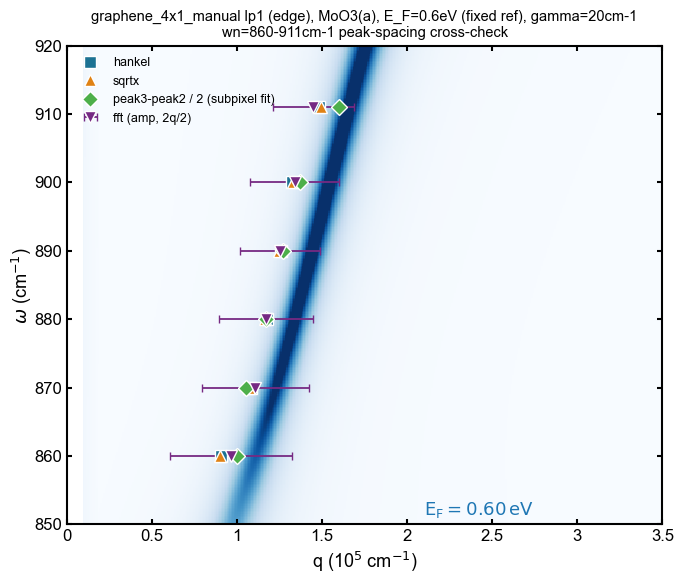

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.60eV_raman_lower.png


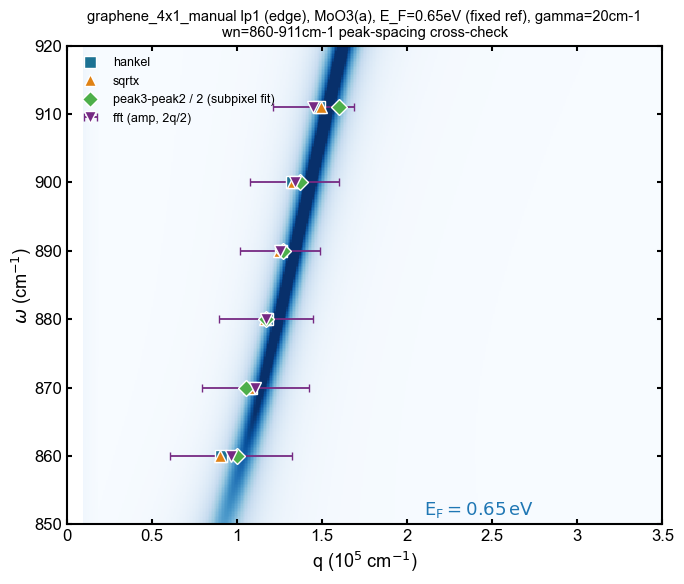

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.65eV.png


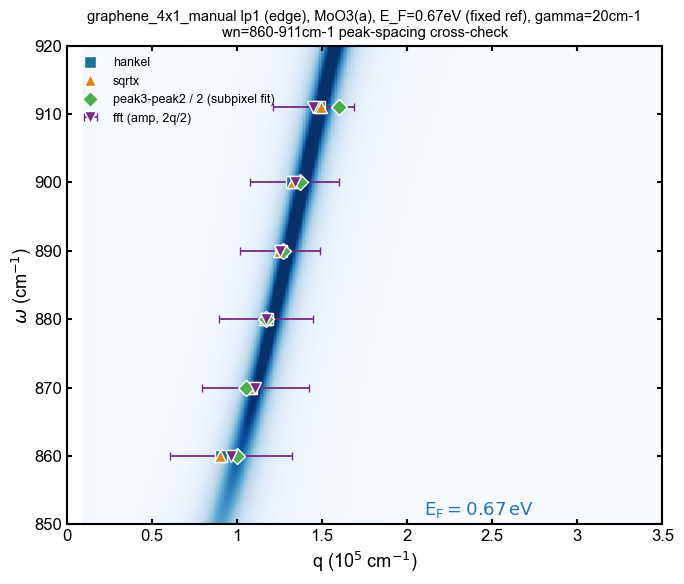

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.67eV.png


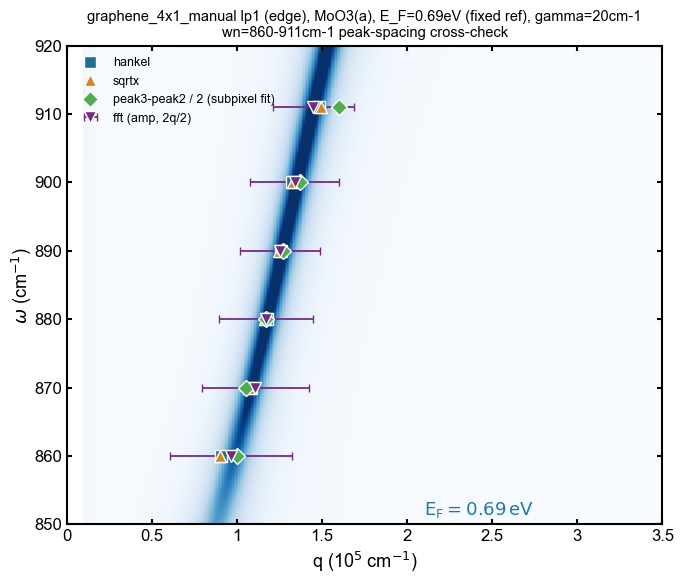

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.69eV.png


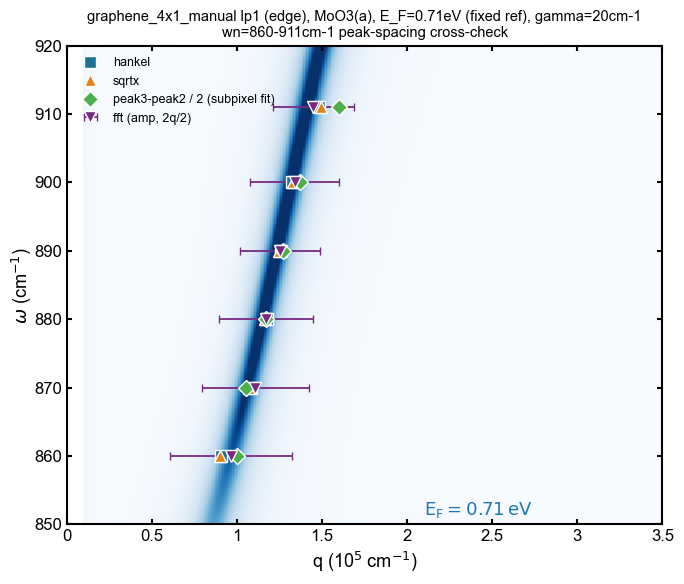

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.71eV.png


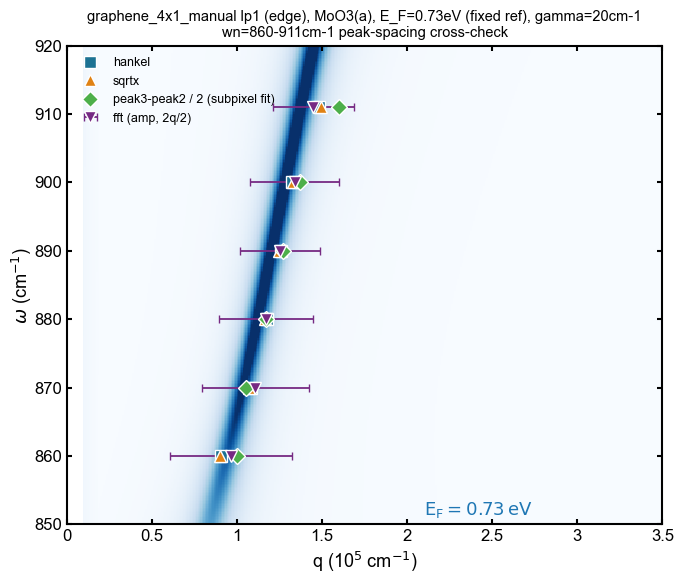

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.73eV.png


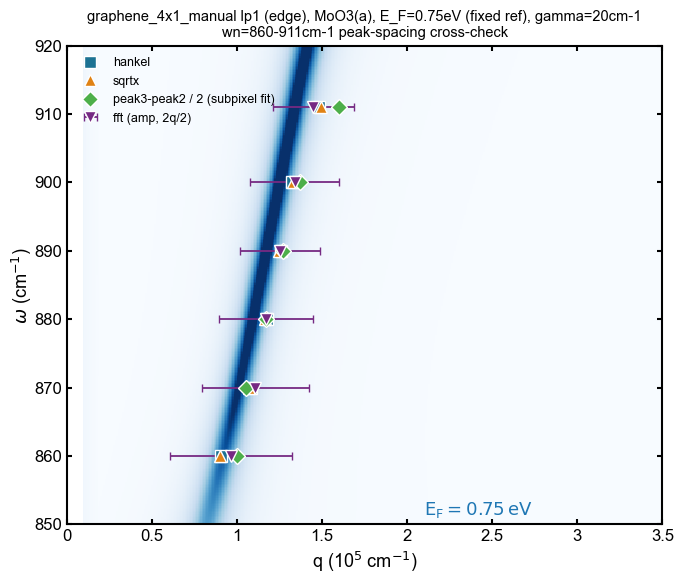

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.75eV.png


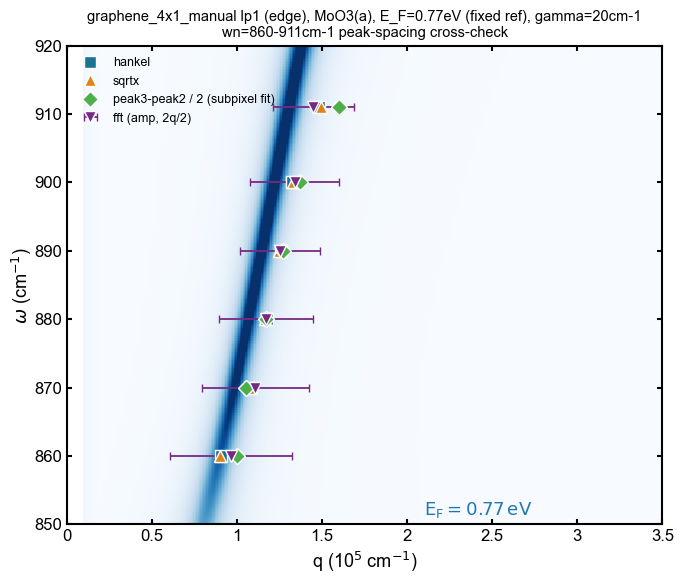

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.77eV.png


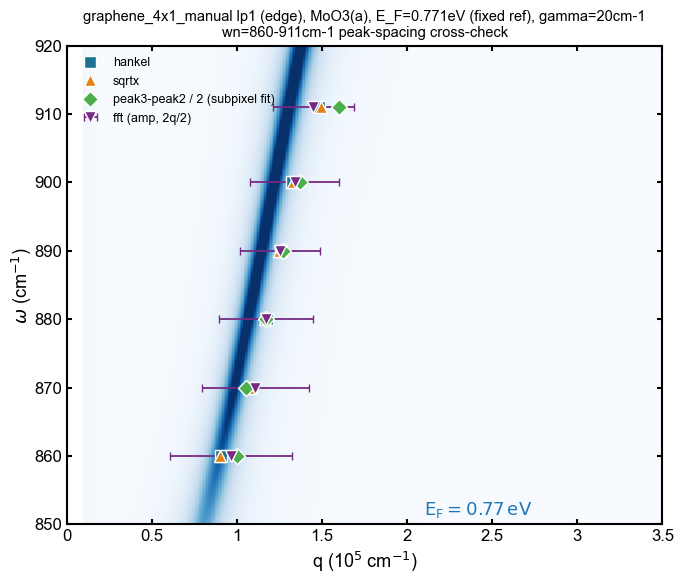

Saved figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/rp_peak_spacing_crosscheck_860to911_Ef0.771eV_cht_fit.png


In [9]:
CSV_PATH = 'figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1/peak_spacing_crosscheck.csv'
SAVE_DIR_ps = 'figures/rp_dispersion/graphene_4x1_manual_lp1_peak_spacing_crosscheck_v1'

# plot_channel_fft always fits all 3 spectra (amp/phase/complex) in one call, and the
# script now saves all 3 to the CSV (fft_q_amp/fft_q_phase/fft_q_complex + _fwhm) --
# switch which one feeds the 'fft' source here without re-running the (slow) script.
FFT_CHANNEL_NB = 'amp'  # 'amp' | 'phase' | 'complex'

df_ps = pd.read_csv(CSV_PATH)
df_ps['q_peak23_fit_div2'] = df_ps['q_peak23_fit'] / 2

FREQS_ps = np.linspace(850, 920, 300)
QS_ps = np.linspace(1e4, 3.5e5, 400)

# 5th tuple element = FWHM column for an x-direction error bar (None = no error bar).
# fft's error bar is FWHM/2 (standard "linewidth as uncertainty" convention).
sources_ps = [('hankel', 'hankel_q', '#1c7293', 's', None),
              ('sqrtx', 'sqrtx_q', '#e08214', '^', None),
              ('peak3-peak2 / 2 (subpixel fit)', 'q_peak23_fit_div2', '#4daf4a', 'D', None),
              (f'fft ({FFT_CHANNEL_NB}, 2q/2)', f'fft_q_{FFT_CHANNEL_NB}', '#762a83', 'v', f'fft_q_{FFT_CHANNEL_NB}_fwhm')]

# NOTE: CSV columns (fft_q_*, hankel_q, etc.) are in 1e5 cm^-1 units (this project's
# convention throughout), but fit_Ef's q_data arg expects raw cm^-1 (matching the
# q(cm-1) = q_1e5*1e5 convention used by build_pts()/fit_all_methods() above) -- must
# multiply by 1e5 before fitting, else E_F silently saturates at the ef_bounds upper edge.
fitted_ef_ps = {}
print(f'Fitted E_F per source (6 pts, wn=860-911cm-1, FFT_CHANNEL_NB={FFT_CHANNEL_NB}):')
for label, col, color, marker, err_col in sources_ps:
    pts_df = df_ps[['wn', col]].dropna()
    if len(pts_df) < 3:
        print(f'  {label:>28s}: skipped -- only {len(pts_df)} pts')
        continue
    ef_fit = fit_Ef(stack_4x1, materials_4x1_a, SUBS, pts_df['wn'].values, pts_df[col].values * 1e5)
    fitted_ef_ps[label] = ef_fit
    print(f'  {label:>28s}: E_F = {ef_fit:.3f} eV')
print('  Raman-measured (edge): ~0.60-0.65 eV')

# 0.60eV (Raman lower bound), 0.65-0.77eV in 0.02eV steps, 0.771eV (previous full-15-wn
# CHT/MoO3(a) fit) -- tweak this list here to add/remove panels without re-running the fits.
ef_scan_ps = [('0.60eV_raman_lower', 0.60)] + \
    [(f'{ef:.2f}eV', ef) for ef in np.round(np.arange(0.65, 0.77 + 1e-9, 0.02), 2)] + \
    [('0.771eV_cht_fit', 0.771)]

for ef_label, EF_REF in ef_scan_ps:
    fig, ax = plt.subplots(figsize=(7, 6))
    rp_schematic(stack_4x1, materials_4x1_a, subs=SUBS, freqs=FREQS_ps, qs=QS_ps,
                 Ef=EF_REF, gamma=GAMMA, figAx=(fig, ax), vmin=0, vmax=8, show_Ef=True, ytickspacing=10)
    for label, col, color, marker, err_col in sources_ps:
        cols = ['wn', col] + ([err_col] if err_col else [])
        pts_df = df_ps[cols].dropna(subset=['wn', col])
        if len(pts_df):
            # QS_ps/the rp_schematic axes are in raw cm^-1 -- col/fwhm values are in 1e5 cm^-1, convert
            xerr = (pts_df[err_col].values * 1e5 / 2) if err_col else None  # FWHM/2 as the error bar
            ax.errorbar(pts_df[col].values * 1e5, pts_df['wn'].values, xerr=xerr, marker=marker,
                        color=color, ms=8, mec='white', mew=1, ls='none', capsize=3, elinewidth=1.3,
                        label=label, zorder=6)
    ax.set_title(f'graphene_4x1_manual lp1 (edge), MoO3(a), E_F={EF_REF}eV (fixed ref), gamma={GAMMA}cm-1\n'
                 f'wn=860-911cm-1 peak-spacing cross-check', fontsize=10.5)
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    fig.tight_layout()
    out_path = f'{SAVE_DIR_ps}/rp_peak_spacing_crosscheck_860to911_Ef{ef_label}.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    print(f'Saved {out_path}')
